In [ ]:
from ssi_fc_data import fc_md_client, model
import config
import datetime

# 1. Thông tin cấu hình (Thay bằng thông tin của bạn)
# config = {
#     "ConsumerID": "YOUR_CONSUMER_ID",
#     "ConsumerSecret": "YOUR_CONSUMER_SECRET",
#     "URL_API": "https://fc-data.ssi.com.vn/",
#     "URL_STREAM": "wss://fc-datahub.ssi.com.vn/v2.0/Market"
# }

In [ ]:
# Khởi tạo client
client = fc_md_client.MarketDataClient(config)

In [ ]:
# 2. Thiết lập thời gian (1 năm gần nhất)
end_date = datetime.date.today().strftime("%d/%m/%Y")
start_date = (datetime.date.today() - datetime.timedelta(days=365)).strftime("%d/%m/%Y")
print(f"Fetching data from {start_date} to {end_date}")

In [ ]:
# Tham số: mã cổ phiếu, từ ngày, đến ngày, trang, số lượng bản ghi/trang
req = model.daily_ohlc("SSI", start_date, end_date, 1, 1000)

In [ ]:
# Gọi API
try:
    response = client.daily_ohlc(config, req)
    # response = response.json()
    print(type(response))
    print(response.keys())
    print(response.get('status'))
    print(response.get('message'))
    print(response.get('totalRecord'))
    print(response.get('data')[-1])  # In bản ghi cuối
except Exception as e:
    print(f"Lỗi khi phân tích phản hồi: {e}")
    exit(1)

In [ ]:
    
if response.get('status') == 'Success':
    data = response.get('data')
    for item in data:
        print(f"Date: {item['TradingDate']} | Open: {item['Open']} | High: {item['High']} | Low: {item['Low']} | Close: {item['Close']} | Volume: {item['Volume']} | Volume: {item['Volume']}")
else:
    print(f"Error: {response.get('message')}")

In [ ]:
def get_stock_history(symbol="SSI"):
    try:
        # 1. Khởi tạo Client (Có thể lỗi nếu URL sai)
        client = fc_md_client.MarketDataClient(config)
        
        end_date = datetime.date.today().strftime("%d/%m/%Y")
        start_date = (datetime.date.today() - datetime.timedelta(days=365)).strftime("%d/%m/%Y")
        
        # 2. Chuẩn bị Request
        req = model.daily_ohlc(symbol, start_date, end_date, 1, 1000)
        
        # 3. Gọi API (Dễ lỗi kết nối mạng nhất)
        response = client.daily_ohlc(config, req)
        
        # Kiểm tra logic nghiệp vụ từ phản hồi của SSI
        if response.get('status') == 'Success':
            data = response.get('data')
            if not data:
                print("Không có dữ liệu trong khoảng thời gian này.")
                return
                
            # for item in data:
            #     print(f"Ngày: {item['TradingDate']} | Đóng: {item['Close']}")
            return data
        else:
            # Lỗi từ phía Server SSI (ví dụ: Sai Token, quá hạn)
            print(f"SSI API Error: {response.get('message')}")

    except ConnectionError:
        print("Lỗi: Không thể kết nối tới server SSI. Vui lòng kiểm tra internet.")
    except KeyError as e:
        print(f"Lỗi: Dữ liệu trả về thiếu trường thông tin: {e}")
    except Exception as e:
        # Bắt các lỗi không mong đợi khác
        print(f"Đã xảy ra lỗi hệ thống: {e}")
    finally:
        print("--- Hoàn tất quá trình truy vấn ---")

if __name__ == '__main__':
    get_stock_history()

In [ ]:
import pandas as pd
import numpy as np

def calculate_yearly_volatility(ssi_data):
    try:
        # 1. Chuyển list dữ liệu từ API sang DataFrame
        df = pd.DataFrame(ssi_data)
        
        # 2. Đảm bảo giá đóng cửa là kiểu số và sắp xếp theo thời gian
        df['Close'] = pd.to_numeric(df['Close'])
        df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
        df = df.sort_values('TradingDate')

        # 3. Tính tỷ suất sinh lời hàng ngày (Daily Return)
        # Công thức: (Giá hôm nay / Giá hôm qua) - 1
        df['Daily_Return'] = df['Close'].pct_change()

        # 4. Tính độ lệch chuẩn hàng ngày
        daily_std = df['Daily_Return'].std()

        # 5. Quy đổi ra độ lệch chuẩn năm (Annualized Volatility)
        yearly_std = daily_std * np.sqrt(252)

        print(f"Độ lệch chuẩn hàng ngày: {daily_std:.4f}")
        print(f"Yearly Standard Deviation (Volatility): {yearly_std:.2%}")
        
        return yearly_std

    except Exception as e:
        print(f"Lỗi khi tính toán: {e}")

# Giả sử 'response_data' là list dữ liệu lấy từ client.daily_ohlc(...)['data']
# calculate_yearly_volatility(response_data)

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_stock_prices(ssi_data, symbol="SSI"):
    try:
        # 1. Chuyển list dữ liệu từ API sang DataFrame
        df = pd.DataFrame(ssi_data)
        
        # 2. Đảm bảo giá đóng cửa là kiểu số và sắp xếp theo thời gian
        df['Close'] = pd.to_numeric(df['Close'])
        df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
        df = df.sort_values('TradingDate')

        # 3. Vẽ biểu đồ giá đóng cửa theo thời gian
        plt.figure(figsize=(12, 6))
        plt.plot(df['TradingDate'], df['Close'], label=f'Giá đóng cửa của {symbol}', color='blue')
        plt.title(f'Biểu đồ giá đóng cửa của {symbol} trong 1 năm gần nhất')
        plt.xlabel('Ngày giao dịch')
        plt.ylabel('Giá đóng cửa (VND)')
        plt.legend()
        plt.grid()
        plt.show()

    except Exception as e:
        print(f"Lỗi khi vẽ biểu đồ: {e}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_stock_performance(ssi_data):
    try:
        # 1. Xử lý dữ liệu
        df = pd.DataFrame(ssi_data)
        df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
        df['Close'] = pd.to_numeric(df['Close'])
        df = df.sort_values('TradingDate')
        
        # Tính tỷ suất sinh lời hàng ngày (%)
        df['Daily_Return'] = df['Close'].pct_change() * 100 

        # 2. Khởi tạo biểu đồ với 2 phần (Giá và Tỷ suất sinh lời)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        plt.subplots_adjust(hspace=0.3)

        # Biểu đồ 1: Giá đóng cửa SSI
        ax1.plot(df['TradingDate'], df['Close'], color='tab:blue', linewidth=2)
        ax1.set_title("Lịch sử Giá đóng cửa SSI (1 năm gần nhất)", fontsize=14, fontweight='bold')
        ax1.set_ylabel("Giá (VNĐ)")
        ax1.grid(True, linestyle='--', alpha=0.7)

        # Biểu đồ 2: Tỷ suất sinh lời hàng ngày
        ax2.bar(df['TradingDate'], df['Daily_Return'], color='tab:red', alpha=0.6)
        ax2.axhline(0, color='black', linewidth=1) # Đường zero
        ax2.set_title("Tỷ suất sinh lời hàng ngày (%)", fontsize=14, fontweight='bold')
        ax2.set_ylabel("% Thay đổi")
        ax2.set_xlabel("Thời gian")
        ax2.grid(True, linestyle='--', alpha=0.5)

        # Hiển thị biểu đồ
        plt.xticks(rotation=45)
        plt.show()

    except Exception as e:
        print(f"Lỗi khi vẽ biểu đồ: {e}")

# Gọi hàm với dữ liệu bạn đã lấy được
# plot_stock_performance(data_from_ssi)

--- Hoàn tất quá trình truy vấn ---
Độ lệch chuẩn hàng ngày: 0.0233
Yearly Standard Deviation (Volatility): 37.01%


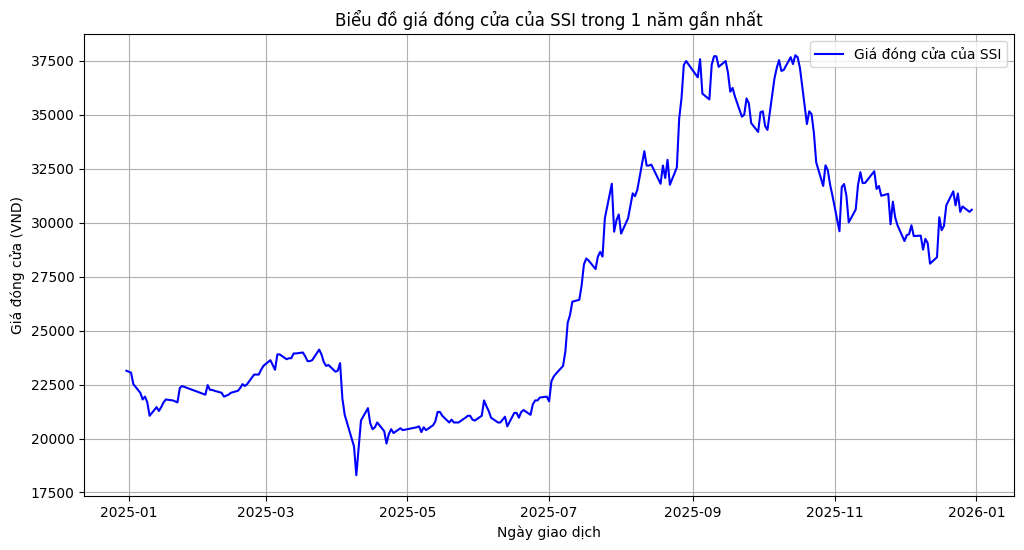

In [13]:
history_data = get_stock_history("SSI")
if history_data:
    calculate_yearly_volatility(history_data)
    plot_stock_prices(history_data, "SSI")
    # plot_stock_performance(history_data)

In [14]:
history_data = get_stock_history("VND")
if history_data:
    calculate_yearly_volatility(history_data)
    plot_stock_prices
    # plot_stock_performance(history_data)

--- Hoàn tất quá trình truy vấn ---
Độ lệch chuẩn hàng ngày: 0.0274
Yearly Standard Deviation (Volatility): 43.50%


--- Hoàn tất quá trình truy vấn ---
Độ lệch chuẩn hàng ngày: 0.0369
Yearly Standard Deviation (Volatility): 58.52%


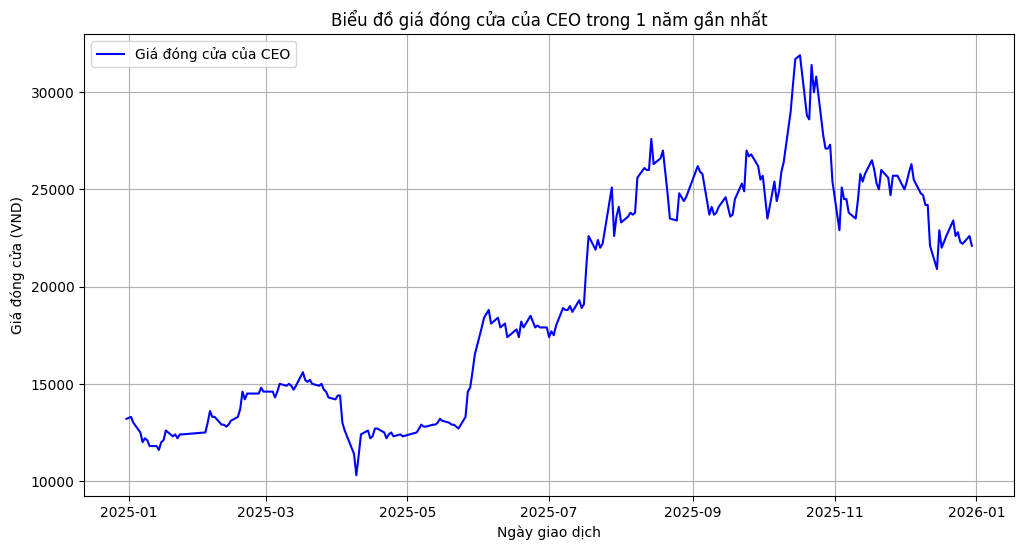

In [15]:
history_data = get_stock_history("CEO")
if history_data:
    calculate_yearly_volatility(history_data)
    plot_stock_prices(history_data, "CEO")
    # plot_stock_performance(history_data)

--- Hoàn tất quá trình truy vấn ---
Độ lệch chuẩn hàng ngày: 0.0209
Yearly Standard Deviation (Volatility): 33.18%


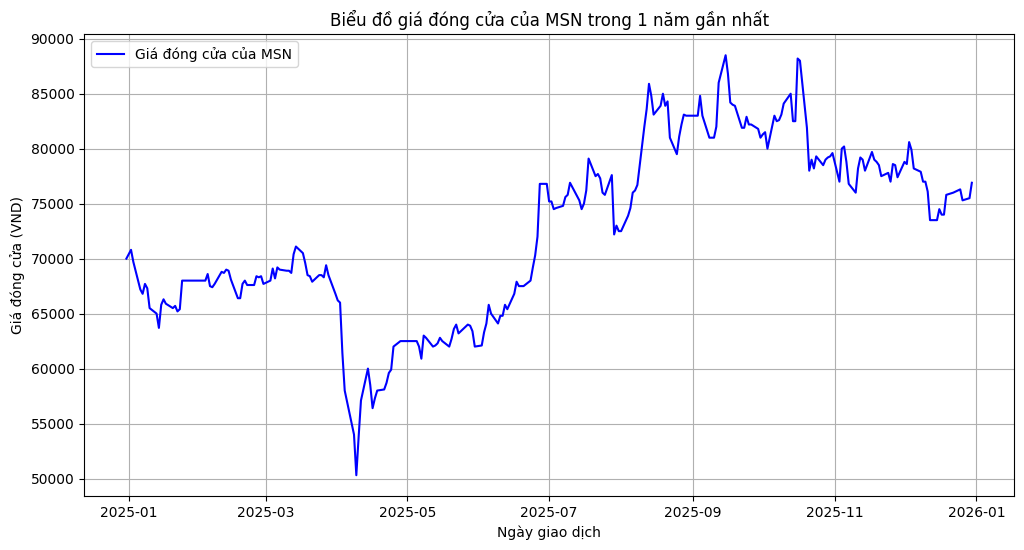

In [16]:
history_data = get_stock_history("MSN")
if history_data:
    calculate_yearly_volatility(history_data)
    plot_stock_prices(history_data, "MSN")
    # plot_stock_performance(history_data)